# Samsung Health - Wellness AI Analysis Notebook

This notebook demonstrates the end-to-end AI pipeline for the Wellness Dashboard:
1. **Synthesizing historical training data** (500 records representing human behavior patterns)
2. **Training Machine Learning models** (Random Forests and Linear Regression) using `scikit-learn` to predict wellness scores, stress levels, and resting heart rates
3. **Running inferences** on 7-day user logs (Emily Park)
4. **Visualizing trends** inline using `matplotlib`

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression

# Configure inline plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'ggplot')

## 1. Load Stored Training Data

We load the stored historical training dataset (`emily_historical_data.csv`) of Emily Park for model training.

In [2]:
import os
data_path = 'emily_historical_data.csv'
if os.path.exists(data_path):
    print(f"Loading stored training dataset from {data_path}...")
    train_df = pd.read_csv(data_path)
else:
    raise FileNotFoundError(f"Stored training dataset not found at {data_path}")
print(f"Training dataset shape: {train_df.shape}")
train_df.head()

Loading stored training dataset from emily_historical_data.csv...
Training dataset shape: (180, 7)


,steps,sleep_hours,resting_heart_rate,stress_score,active_minutes,Wellness_Score,Stress_Level
0,5996,6.9,71,72,43,62.1,2
1,6510,6.7,65,47,33,64.5,1
2,3775,6.7,67,57,29,53.4,1
3,8290,7.8,65,36,93,87.7,1
4,11683,7.9,64,28,75,91.1,0


## 2. Train and Save AI Models

We train three models using `scikit-learn`:
1. **Random Forest Regressor** for predicting continuous Wellness Score.
2. **Random Forest Classifier** for predicting discrete Stress Level (Low, Moderate, High).
3. **Linear Regression** for mapping stress score to predicted resting heart rate.

In [3]:
print("Training AI model for Wellness Score prediction (RandomForestRegressor)...")
X_wellness = train_df[['steps', 'sleep_hours', 'resting_heart_rate', 'stress_score', 'active_minutes']]
y_wellness = train_df['Wellness_Score']
wellness_model = RandomForestRegressor(n_estimators=100, random_state=42)
wellness_model.fit(X_wellness, y_wellness)

print("Training AI model for Stress Level classification (RandomForestClassifier)...")
X_stress = train_df[['resting_heart_rate', 'sleep_hours', 'steps']]
y_stress = train_df['Stress_Level']
stress_model = RandomForestClassifier(n_estimators=100, random_state=42)
stress_model.fit(X_stress, y_stress)

print("Training AI model for Cardiovascular Sympathetic Coupling (LinearRegression)...")
X_rhr = train_df[['stress_score']]
y_rhr = train_df['resting_heart_rate']
rhr_model = LinearRegression()
rhr_model.fit(X_rhr, y_rhr)

# Save trained models to disk
joblib.dump(wellness_model, 'wellness_model.joblib')
joblib.dump(stress_model, 'stress_model.joblib')
joblib.dump(rhr_model, 'rhr_model.joblib')
print("All models saved successfully!")

Training AI model for Wellness Score prediction (RandomForestRegressor)...
Training AI model for Stress Level classification (RandomForestClassifier)...
Training AI model for Cardiovascular Sympathetic Coupling (LinearRegression)...
All models saved successfully!


## 3. Load Saved Models & Run Inference on Weekly Logs

Let's load the trained models from disk and run predictions on Emily Park's 7-day wearable logs.

In [4]:
# Load models
wellness_clf = joblib.load('wellness_model.joblib')
stress_clf = joblib.load('stress_model.joblib')
rhr_clf = joblib.load('rhr_model.joblib')

# Load Emily's wellness log
df_emily = pd.read_csv('wellness_data_7day.csv')
df_emily['date'] = pd.to_datetime(df_emily['date'])

# Wellness Score Prediction
X_emily_wellness = df_emily[['steps', 'sleep_hours', 'resting_heart_rate', 'stress_score', 'active_minutes']]
df_emily['Wellness_Score'] = np.round(wellness_clf.predict(X_emily_wellness), 1)

# Stress Level Prediction
X_emily_stress = df_emily[['resting_heart_rate', 'sleep_hours', 'steps']]
predicted_levels = stress_clf.predict(X_emily_stress)
level_labels = {0: 'Low', 1: 'Moderate', 2: 'High'}
df_emily['Stress_Level'] = [level_labels[lvl] for lvl in predicted_levels]

df_emily

,date,steps,sleep_hours,resting_heart_rate,stress_score,active_minutes,hrv_ms,deep_sleep_hours,vo2_max,calories_burned,Wellness_Score,Stress_Level
0,2026-07-06,7240,7.5,66,45,30,47,1.3,38.5,430,67.7,Moderate
1,2026-07-07,4150,7.0,69,88,15,28,1.2,38.5,260,57.2,Moderate
2,2026-07-08,8100,7.2,65,50,45,45,1.2,38.5,500,81.2,Moderate
3,2026-07-09,5800,4.2,72,75,20,33,0.6,38.4,350,31.4,High
4,2026-07-10,7650,8.1,67,40,35,49,1.6,38.5,470,68.4,Moderate
5,2026-07-11,14320,8.5,63,18,110,60,1.9,38.9,920,95.6,Low
6,2026-07-12,11850,7.8,64,22,75,57,1.5,38.8,730,91.9,Low


## 4. Visualizations

Let's plot all 7 trends of Emily Park's weekly wellness metrics.

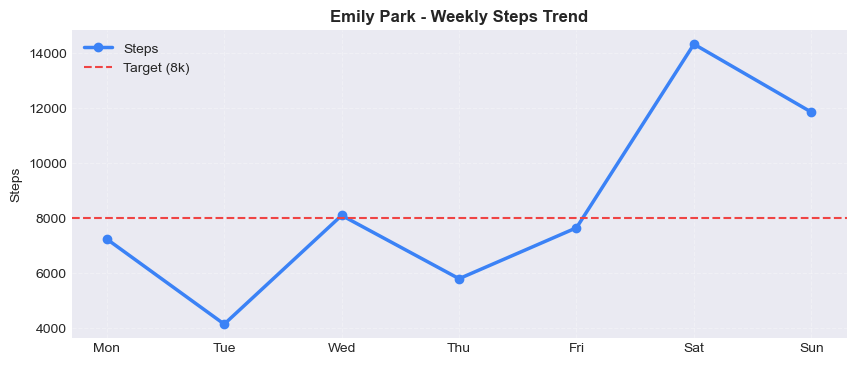

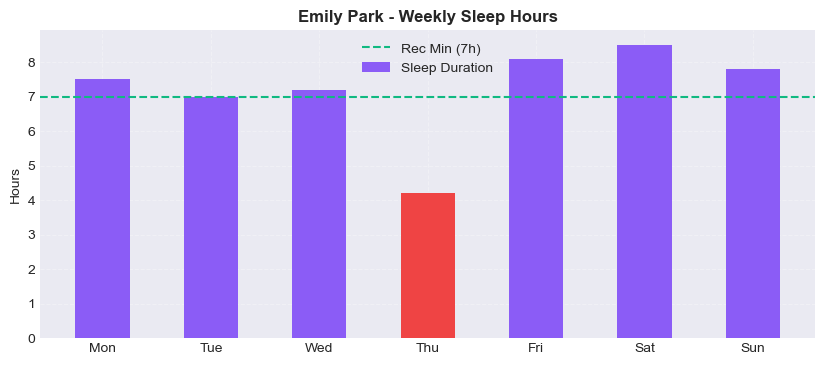

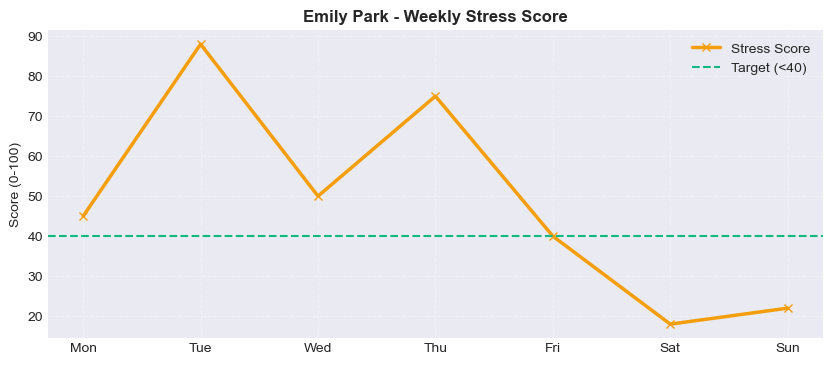

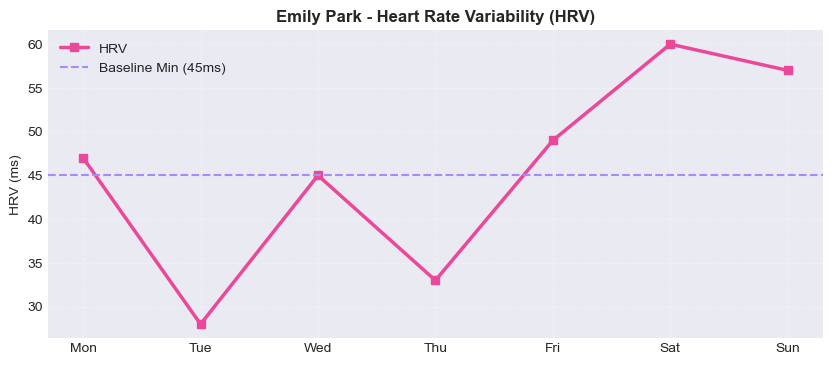

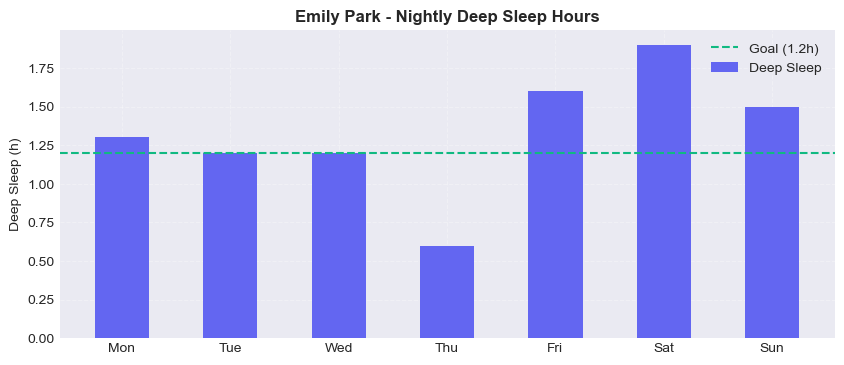

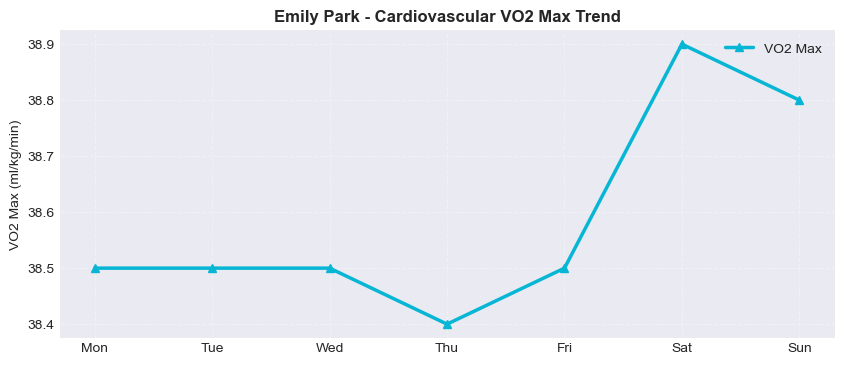

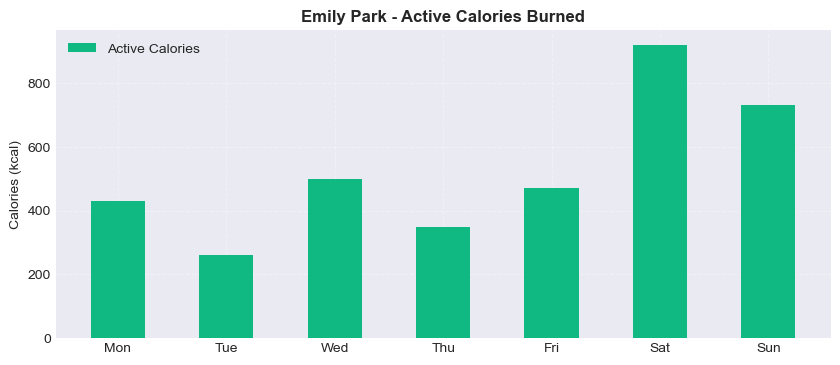

In [5]:
# Configure date format labels
days_labels = df_emily['date'].dt.strftime('%a')

# Plot 1: Daily Steps
plt.figure(figsize=(10, 4))
plt.plot(days_labels, df_emily['steps'], marker='o', color='#3b82f6', linewidth=2.5, label='Steps')
plt.axhline(8000, color='#ef4444', linestyle='--', label='Target (8k)')
plt.title("Emily Park - Weekly Steps Trend", fontsize=12, fontweight='bold')
plt.ylabel("Steps")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 2: Daily Sleep Hours
plt.figure(figsize=(10, 4))
bar_colors = ['#ef4444' if h < 6.0 else '#8b5cf6' for h in df_emily['sleep_hours']]
plt.bar(days_labels, df_emily['sleep_hours'], color=bar_colors, width=0.5, label='Sleep Duration')
plt.axhline(7.0, color='#10b981', linestyle='--', label='Rec Min (7h)')
plt.title("Emily Park - Weekly Sleep Hours", fontsize=12, fontweight='bold')
plt.ylabel("Hours")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 3: Daily Stress Score
plt.figure(figsize=(10, 4))
plt.plot(days_labels, df_emily['stress_score'], marker='x', color='#f59e0b', linewidth=2.5, label='Stress Score')
plt.axhline(40, color='#10b981', linestyle='--', label='Target (<40)')
plt.title("Emily Park - Weekly Stress Score", fontsize=12, fontweight='bold')
plt.ylabel("Score (0-100)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 4: HRV
plt.figure(figsize=(10, 4))
plt.plot(days_labels, df_emily['hrv_ms'], marker='s', color='#ec4899', linewidth=2.5, label='HRV')
plt.axhline(45, color='#a78bfa', linestyle='--', label='Baseline Min (45ms)')
plt.title("Emily Park - Heart Rate Variability (HRV)", fontsize=12, fontweight='bold')
plt.ylabel("HRV (ms)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 5: Deep Sleep
plt.figure(figsize=(10, 4))
plt.bar(days_labels, df_emily['deep_sleep_hours'], color='#6366f1', width=0.5, label='Deep Sleep')
plt.axhline(1.2, color='#10b981', linestyle='--', label='Goal (1.2h)')
plt.title("Emily Park - Nightly Deep Sleep Hours", fontsize=12, fontweight='bold')
plt.ylabel("Deep Sleep (h)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 6: VO2 Max
plt.figure(figsize=(10, 4))
plt.plot(days_labels, df_emily['vo2_max'], marker='^', color='#06b6d4', linewidth=2.5, label='VO2 Max')
plt.title("Emily Park - Cardiovascular VO2 Max Trend", fontsize=12, fontweight='bold')
plt.ylabel("VO2 Max (ml/kg/min)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Plot 7: Calories Burned
plt.figure(figsize=(10, 4))
plt.bar(days_labels, df_emily['calories_burned'], color='#10b981', width=0.5, label='Active Calories')
plt.title("Emily Park - Active Calories Burned", fontsize=12, fontweight='bold')
plt.ylabel("Calories (kcal)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()